In this notebook, we fit a simple xgboost model using a very tiny dataset. We analyze
in details the tree growing process and try to replicate the growing process using the 
theoretical computations. 

In [109]:
import xgboost as xgb
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# prepare data 
We generate the dataset for model training.  
Assume there are 4 features. All 4 features are independent.  
* first feature: discrete uniform in [0, 1, 2, 3]
* second features: discrete uniform in [0, 1, 2, 3]
* third features: discrete uniform in [0, 1, 2, 3, 4, 5]
* fourth features: discrete uniform in [0, 1, 2, 3, 4]

In [3]:
# we define a function, the function has outputs being 0, 1, 2 
def target_function(x1, x2, x3):
    if x3 >= 3:
        return 2
    if x1 * x2 < 2.5:
        return 0
    return 1

In [4]:
# ...existing code...
sample_size = 20
random_state = 42

rng = np.random.RandomState(random_state)

# generate features
feature1L = rng.randint(0, 4, size=sample_size)
feature2L = rng.randint(0, 4, size=sample_size)
feature3L = rng.randint(0, 6, size=sample_size)
feature4L = rng.randint(0, 5, size=sample_size)

# the dataset is the product of the features
dataR = pd.DataFrame({
    'feature1': feature1L,
    'feature2': feature2L,
    'feature3': feature3L,
    'feature4': feature4L
})

dataR.head()


,feature1,feature2,feature3,feature4
0,2,1,2,1
1,3,0,1,1
2,0,1,3,0
3,2,3,3,1
4,2,3,5,4


In [5]:
# generate the target variable 
targetsL = [target_function(x1, x2, x3) for x1, x2, x3 in zip(feature1L, feature2L, feature3L)]
rng = np.random.RandomState(random_state)

# randomly change the target variable to introduce noise
for i in range(sample_size):
    if rng.rand() < 0.1:
        print(i)  # 10% chance to change the target
        targetsL[i] = rng.randint(0, 3)

# add the generated target variable to the dataset
dataR['target'] = targetsL
dataR.head()

6
9
12
15


,feature1,feature2,feature3,feature4,target
0,2,1,2,1,0
1,3,0,1,1,0
2,0,1,3,0,2
3,2,3,3,1,2
4,2,3,5,4,2


# prepare function for theoretical analysis

In [6]:
# soft max function to convert the target variable to probabilities
def softmax(y: np.ndarray) -> np.ndarray:
    ''' 
    Compute the softmax of vector y.
    Parameters:
    y : array-like, shape (num_samples, num_classes), raw scores for each class.
    Returns:
    p: array-like, shape (num_samples, num_classes), probabilities for each class.
        
    '''
    e_y = np.exp(y - np.max(y))  # subtract max for numerical stability
    return e_y / e_y.sum(axis=1, keepdims=True)

In [7]:
# test above function 
y_test = np.array([[1, 2, 3], [0, 1, -1]])
print("Softmax probabilities:\n", softmax(y_test))

Softmax probabilities:
 [[0.09003057 0.24472847 0.66524096]
 [0.24472847 0.66524096 0.09003057]]


In [8]:
# get the gradient function for the softmax logloss function
def gradient(
        y: np.ndarray, 
        y_true: np.ndarray
        ) -> np.ndarray:
    '''
    Compute the gradient of the softmax logloss function.
    
    Parameters:
    y : array-like, shape (num_samples, num_classes), raw scores for each class.
    y_true : array-like, shape (num_samples, num_classes), one-hot encoded true labels.
    
    Returns:
    grad: array-like, shape (num_samples, num_classes), gradient of the loss function.
    '''
    # get the softmax probabilities
    p = softmax(y)
    # calculate the gradient
    grad = p - y_true
    return grad

# compute the hessian for the softmax logloss function, only the diagonal part
def hessian_diagonal_xgb(
        y: np.ndarray
        ) -> np.ndarray:
    '''
    Compute the diagonal of the hessian of the softmax logloss function.
    
    Parameters:
    y : array-like, shape (num_samples, num_classes), raw scores for each class.
    
    Returns:
    hess: array-like, shape (num_samples, num_classes), diagonal of the hessian.
    '''
    # get the softmax probabilities
    p = softmax(y)
    # calculate the diagonal hessian
    hess = 2 * p * (1 - p)
    return hess


In [9]:
# closed formula for the optimal leaf score 
def optimal_leaf_score_obj(
        grad_j: np.ndarray,
        hess_j: np.ndarray, 
        reg_lambda: float,
        reg_alpha: float
        ) -> (float, float):

    ''' 
    Parameters:
        grad_j: the gradient (only j-th coordinate) for all the samples in the leaf
            shape (num_samples,)
        hess_j: the diagonal of the hessian (only j-th coordinate) 
            for all the samples in the leaf, shape (num_samples,)
        eta: the learning rate
        reg_lambda: the L2 regularization term
        reg_alpha: the L1 regularization term
    Returns:
        The optimal leaf score and the objective value

    '''

    w = np.sum(grad_j)
    A = reg_lambda + np.sum(hess_j)

    if w < -reg_alpha:
        sw = -(w + reg_alpha)
    elif w > reg_alpha:
        sw = -(w - reg_alpha)
    else:
        sw = 0.0
    opt_score = sw / A

    # for xgboost package implementation, the objective function
    # doe not have the half factor
    obj = - sw**2 / A

    return opt_score, obj


# train xgboost model  
We train a multi-class classification xgboost model.   
And we will change different parameters to see the impact on the model training.  

In [10]:
org_model = xgb.XGBClassifier(
    random_state=random_state,
    objective='multi:softmax',
    booster='gbtree',
    tree_method='exact',
    eval_metric='mlogloss',

    n_estimators=5,
    max_depth=3,
    learning_rate=0.1,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    # the sum of the hessian for all the samples in a given leaf node
    # mush >= min_child_weight for the split. 
    min_child_weight=1,

)

In [11]:
# train the model
feature_colsL = ['feature1', 'feature2', 'feature3', 'feature4']
X = dataR[feature_colsL]
y = dataR['target']

org_model.fit(X, y,
    eval_set=[(X, y)],
    verbose=True,
)

[0]	validation_0-mlogloss:1.01071
[1]	validation_0-mlogloss:0.93551
[2]	validation_0-mlogloss:0.87057
[3]	validation_0-mlogloss:0.81386
[4]	validation_0-mlogloss:0.76402


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=5, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
# get the trees in the model training 
trees_df = org_model.get_booster().trees_to_dataframe()
trees_df.head()


,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,feature3,3.0,0-1,0-2,0-1,5.185039,8.888888,NaN
1,0,1,0-1,feature1,3.0,0-3,0-4,0-3,0.206609,4.000000,NaN
2,0,2,0-2,feature3,4.0,0-5,0-6,0-5,0.836282,4.888888,NaN
3,0,3,0-3,Leaf,NaN,NaN,NaN,NaN,0.140964,2.666667,NaN
4,0,4,0-4,Leaf,NaN,NaN,NaN,NaN,0.062791,1.333333,NaN


In [13]:
# (num of iterations * num of classes) trees are expected
trees_df['Tree'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## first iteration
The base value by default is 0 for all three (num of classes) trees. 

<Figure size 1000x500 with 0 Axes>

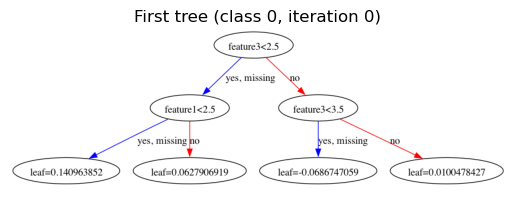

In [14]:
# plot the first tree
plt.figure(figsize=(10, 5))
xgb.plot_tree(org_model, tree_idx=0)
plt.title("First tree (class 0, iteration 0)")
plt.show()

In [15]:
trees_df.query('Tree == 0')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,feature3,3.0,0-1,0-2,0-1,5.185039,8.888888,NaN
1,0,1,0-1,feature1,3.0,0-3,0-4,0-3,0.206609,4.000000,NaN
2,0,2,0-2,feature3,4.0,0-5,0-6,0-5,0.836282,4.888888,NaN
3,0,3,0-3,Leaf,NaN,NaN,NaN,NaN,0.140964,2.666667,NaN
4,0,4,0-4,Leaf,NaN,NaN,NaN,NaN,0.062791,1.333333,NaN
5,0,5,0-5,Leaf,NaN,NaN,NaN,NaN,-0.068675,2.666667,NaN
6,0,6,0-6,Leaf,NaN,NaN,NaN,NaN,0.010048,2.222222,NaN


In [16]:
trees_df.query('Tree == 1')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
7,1,0,1-0,feature2,3.0,1-1,1-2,1-1,0.978570,8.888888,NaN
8,1,1,1-1,Leaf,NaN,NaN,NaN,NaN,-0.072232,6.222222,NaN
9,1,2,1-2,Leaf,NaN,NaN,NaN,NaN,-0.000000,2.666667,NaN


# theoretical replication 


In [17]:
# we need to make y values to be one-hot encoded
y_one_hot_true = (pd.get_dummies(y).values) * 1
y_one_hot_true.shape

(20, 3)

In [18]:
# try to replicate the growing of first tree. 

num_classes = 3  # number of classes
# base score by default is 0, and all samples belong to one single node
base_score = 0.5
y_0 = np.zeros((sample_size, num_classes)) + base_score  # num_samples = 20, num_classes = 3

# update current predictions 
dataR[['pred_0', 'pred_1', 'pred_2']] = y_0

In [19]:
# get the gradient and hessian for this base score 
G0 = gradient(y_0, y_one_hot_true)
H0 = hessian_diagonal_xgb(y_0)

In [20]:
# to avoid repeated computing the gradient and hessian
# we save the results 
dataR[['grad_0', 'grad_1', 'grad_2']] = G0
dataR[['hess_0', 'hess_1', 'hess_2']] = H0

In [21]:
H0.shape

(20, 3)

In [22]:
H0[0], G0[0]

(array([0.44444444, 0.44444444, 0.44444444]),
 array([-0.66666667,  0.33333333,  0.33333333]))

In [25]:
org_model.learning_rate, org_model.reg_lambda, org_model.reg_alpha, org_model.gamma

(0.1, 0.1, 0.1, 0.1)

In [26]:
# for each class, get the optimal leaf score
leaf_scores = []
# and the objective value
loss_objectives = []
for j in range(num_classes):
    grad_j = G0[:, j]
    hess_j = H0[:, j]
    leaf_score, obj_value = optimal_leaf_score_obj(
        grad_j, hess_j, 
    
        org_model.reg_lambda,
        org_model.reg_alpha
    )
    leaf_scores.append(leaf_score)
    loss_objectives.append(obj_value)

In [27]:
leaf_scores

[0.3597033374536466, -0.5080346106304079, 0.1372064276885044]

In [28]:
loss_objectives

[-1.1630407911001241, -2.3200247218788626, -0.1692212608158222]

## first iteration - class 0
Check class 0 first.  
Because there is no missing value for all features, we do not consider the split  
separating the missing and non-missing part. 

In [29]:
# for each features, get the possible split values
split_values_dict = {}
for i in range(len(feature_colsL)):
    feature_name = feature_colsL[i]
    sorted_values = np.sort(dataR[feature_name].unique())
    split_values = [(a+b)/2 for a, b in zip(sorted_values[:-1], sorted_values[1:])]
    split_values_dict[feature_name] = split_values
split_values_dict

{'feature1': [0.5, 1.5, 2.5],
 'feature2': [0.5, 1.5, 2.5],
 'feature3': [0.5, 1.5, 2.5, 3.5, 4.5],
 'feature4': [0.5, 1.5, 2.5, 3.5]}

In [30]:
def separate_data(
        data: pd.DataFrame,
        feature_name: str,
        split_value: float
        ) -> (pd.DataFrame, pd.DataFrame):
    '''
    Split the data into two parts based on the feature and split value.
    '''
    left_data = data[data[feature_name] < split_value]
    right_data = data[data[feature_name] >= split_value]
    return left_data, right_data

In [34]:
# combine the steps computing objective function together 
# this function gives the optimal leaf score, the objective value and the cover.
# the cover is the sum of the hessian for all the samples in the leaf
def compute_objective(
        data: pd.DataFrame,
        class_index: int,
        # parameters
        reg_lambda: float,
        reg_alpha: float, 
    
):
    '''
    Compute the objective function of class_index for all the data in a leaf node 
    given the predicted raw scores
    '''
    grad_j = data[f'grad_{class_index}'].values
    hess_j = data[f'hess_{class_index}'].values

    v, obj = optimal_leaf_score_obj(
        grad_j, hess_j, 
        reg_lambda, reg_alpha
    )
    return obj, v, np.sum(hess_j)

### example: feature 3, split_value = 2.5

In [32]:
split_value = 2.5
feature_name = 'feature3'
left_data, right_data = separate_data(dataR, feature_name, split_value)
left_data.shape, right_data.shape

((9, 14), (11, 14))

In [36]:
# compute the loss for left nodes
left_obj, left_opt_value, left_cover = compute_objective(
    data=left_data,
    class_index = 0,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
)

# compute the loss for right nodes
right_obj, right_opt_value, right_cover = compute_objective(
    data=right_data,
    class_index = 0,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,

)

left_obj, left_opt_value, left_cover, right_obj, right_opt_value, right_cover

(-5.856097560975614,
 1.1951219512195126,
 4.0,
 -0.4919821826280621,
 -0.3140311804008908,
 4.888888888888889)

In [37]:
# compare with the objective function before splitting 
loss_objectives[0] - (left_obj + right_obj)

5.185038952503552

### other options 
In next session, we range through all features and all split values. 

In [38]:
class_index = 0

In [40]:
children_node_info = []
for feature in feature_colsL:
    for split_value in split_values_dict[feature]:
        print(f"Feature: {feature}, Split value: {split_value}")
        left_data, right_data = separate_data(dataR, feature, split_value)
        
        # considering the special case of 
        if left_data.empty or right_data.empty:
            continue
        left_obj, left_opt_value, left_cover = compute_objective(
            data=left_data,
            class_index = class_index,
            reg_lambda=org_model.reg_lambda,
            reg_alpha=org_model.reg_alpha,

        )

        # since we have a restriction on the min_child_weight, we need to check 
        # if the left node has enough samples
        if left_cover < org_model.min_child_weight:
            print('Not enough samples for left node')
            continue
        
        right_obj, right_opt_value, right_cover = compute_objective(
            data=right_data,
            class_index = class_index,
            reg_lambda=org_model.reg_lambda,
            reg_alpha=org_model.reg_alpha,
        
        )
        if right_cover < org_model.min_child_weight:
            print('Not enough samples for right node')
            continue

        gain = loss_objectives[class_index] - (left_obj + right_obj)
        children_node_info.append({
            'feature': feature,
            'split_value': split_value,
            'left_obj': left_obj,
            'left_opt_value': left_opt_value,
            'left_cover': left_cover,
            'right_obj': right_obj,
            'right_opt_value': right_opt_value,
            'right_cover': right_cover,
            'gain': gain
        })

children_node_info_df = pd.DataFrame(children_node_info).sort_values(
    by='gain', ascending=False)
children_node_info_df.head(10)  # show top 10 splits by gain


Feature: feature1, Split value: 0.5
Feature: feature1, Split value: 1.5
Feature: feature1, Split value: 2.5
Feature: feature2, Split value: 0.5
Feature: feature2, Split value: 1.5
Feature: feature2, Split value: 2.5
Feature: feature3, Split value: 0.5
Feature: feature3, Split value: 1.5
Feature: feature3, Split value: 2.5
Feature: feature3, Split value: 3.5
Feature: feature3, Split value: 4.5
Feature: feature4, Split value: 0.5
Not enough samples for left node
Feature: feature4, Split value: 1.5
Feature: feature4, Split value: 2.5
Feature: feature4, Split value: 3.5


,feature,split_value,left_obj,left_opt_value,left_cover,right_obj,right_opt_value,right_cover,gain
8,feature3,2.5,-5.856098,1.195122,4.000000,-0.491982,-0.314031,4.888889,5.185039
4,feature2,1.5,-3.548015,0.776938,5.777778,-0.473702,-0.384083,3.111111,2.858677
5,feature2,2.5,-2.834622,0.669596,6.222222,-0.292771,-0.325301,2.666667,1.964352
3,feature2,0.5,-3.039759,1.048193,2.666667,-0.008612,0.036907,6.222222,1.885330
6,feature3,0.5,-2.518605,1.325581,1.333333,-0.198694,0.161103,7.555556,1.554258
7,feature3,1.5,-2.147847,0.961722,2.222222,-0.119704,0.133005,6.666667,1.104511
11,feature4,1.5,-0.000000,0.000000,4.000000,-2.095546,0.648107,4.888889,0.932505
2,feature1,2.5,-1.653603,0.511424,6.222222,-0.000000,0.000000,2.666667,0.490562
0,feature1,0.5,-1.307101,0.834320,1.777778,-0.340370,0.217257,7.111111,0.484430
12,feature4,2.5,-0.070660,0.124694,4.444444,-1.449633,0.564792,4.444444,0.357253


The first split value is 2.5 for feature3

In [41]:
def get_split_value_dict(
    dataR: pd.DataFrame,
    feature_colsL: list,
):
    split_values_dict = {}
    for feature in feature_colsL:
        sorted_values = np.sort(dataR[feature].unique())
        split_values = [(a + b) / 2 for a, b in zip(sorted_values[:-1], sorted_values[1:])]
        split_values_dict[feature] = split_values
    return split_values_dict

In [42]:
final_split_feature = 'feature3'
final_split_value = 2.5
left_data, right_data = separate_data(
    dataR, final_split_feature, final_split_value)
left_data.shape, right_data.shape

((9, 14), (11, 14))

In [43]:
# get the objective value after the split 
left_obj_v = children_node_info_df.query(
    f"feature == '{final_split_feature}' and split_value == {final_split_value}"
).iloc[0]['left_obj']
right_obj_v = children_node_info_df.query(
    f"feature == '{final_split_feature}' and split_value == {final_split_value}"
).iloc[0]['right_obj']
left_obj_v, right_obj_v

(-5.856097560975614, -0.4919821826280621)

#### left branch: feature3 < 2.5

In [44]:
l_split_values_dict = get_split_value_dict(
    left_data, feature_colsL)
l_split_values_dict

{'feature1': [1.0, 2.5],
 'feature2': [0.5, 2.0],
 'feature3': [0.5, 1.5],
 'feature4': [1.5, 2.5, 3.5]}

In [45]:
left_data

,feature1,feature2,feature3,feature4,target,pred_0,pred_1,pred_2,grad_0,grad_1,grad_2,hess_0,hess_1,hess_2
0,2,1,2,1,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
1,3,0,1,1,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
7,0,1,2,3,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
10,2,0,0,4,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
11,2,0,2,2,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
13,2,1,2,3,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
15,0,0,0,3,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
16,3,3,1,1,1,0.5,0.5,0.5,0.333333,-0.666667,0.333333,0.444444,0.444444,0.444444
18,3,0,0,3,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444


In [48]:
# make the above ranging over all possible features and split values into a function 
def range_over_features_and_splits(
        data: pd.DataFrame,
        feature_colsL: list,
        class_index: int,
        eta: float,
        reg_lambda: float,
        reg_alpha: float,
        min_child_weight: float,
        loss_before_split: float,
        gamma: float
    ) -> pd.DataFrame:
    '''
    Range over all features and split values to find the best split.
    '''
    children_node_info = []
    split_values_dict = get_split_value_dict(data, feature_colsL)
    
    for feature in feature_colsL:
        for split_value in split_values_dict[feature]:
            left_data, right_data = separate_data(data, feature, split_value)
            print(f"Feature: {feature}, Split value: {split_value};" \
                  + f"left_data: {left_data.shape}, right_data: {right_data.shape}")
            
            if left_data.empty or right_data.empty:
                continue
            
            left_obj, left_opt_value, left_cover = compute_objective(
                data=left_data,
                class_index=class_index,
                reg_lambda=reg_lambda,
                reg_alpha=reg_alpha,
            )

            if left_cover < min_child_weight:
                print('Not enough samples for left node')
                continue
            
            right_obj, right_opt_value, right_cover = compute_objective(
                data=right_data,
                class_index=class_index,
                reg_lambda=reg_lambda,
                reg_alpha=reg_alpha,
            )
            
            if right_cover < min_child_weight:
                print('Not enough samples for right node')
                continue
            gain = loss_before_split - (left_obj + right_obj)

            # make sure the gain is larger than gamma
            if gain < gamma:
                print(f"Gain {gain} is less than gamma {gamma}, skipping this split.")
                continue
            children_node_info.append({
                'feature': feature,
                'split_value': split_value,
                'left_obj': left_obj,
                'left_opt_value': left_opt_value,
                'left_cover': left_cover,
                'right_obj': right_obj,
                'right_opt_value': right_opt_value,
                'right_cover': right_cover,
                'gain': gain
            })
    info_df = pd.DataFrame(children_node_info)
    if info_df.empty:
        print("No valid splits found.")
        return info_df
    # sort by gain
    info_df = info_df.sort_values(by='gain', ascending=False)
    return info_df

In [49]:

l_children_node_info_df = range_over_features_and_splits(
    data=left_data,
    feature_colsL=feature_colsL,
    class_index=0,
    eta=org_model.learning_rate,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
    min_child_weight=org_model.min_child_weight,
    loss_before_split=left_obj_v,
    gamma=org_model.gamma
)

l_children_node_info_df.head(10)  # show top 10 splits by gain

Feature: feature1, Split value: 1.0;left_data: (2, 14), right_data: (7, 14)
Not enough samples for left node
Feature: feature1, Split value: 2.5;left_data: (6, 14), right_data: (3, 14)
Feature: feature2, Split value: 0.5;left_data: (5, 14), right_data: (4, 14)
Gain -0.04708309366155028 is less than gamma 0.1, skipping this split.
Feature: feature2, Split value: 2.0;left_data: (8, 14), right_data: (1, 14)
Not enough samples for right node
Feature: feature3, Split value: 0.5;left_data: (3, 14), right_data: (6, 14)
Gain -0.29773387366824533 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 1.5;left_data: (5, 14), right_data: (4, 14)
Gain -0.19996664735482117 is less than gamma 0.1, skipping this split.
Feature: feature4, Split value: 1.5;left_data: (3, 14), right_data: (6, 14)
Feature: feature4, Split value: 2.5;left_data: (4, 14), right_data: (5, 14)
Gain -0.04708309366155028 is less than gamma 0.1, skipping this split.
Feature: feature4, Split value: 3.5;left_

,feature,split_value,left_obj,left_opt_value,left_cover,right_obj,right_opt_value,right_cover,gain
0,feature1,2.5,-5.497590,1.409639,2.666667,-0.565116,0.627907,1.333333,0.206609
1,feature4,1.5,-0.565116,0.627907,1.333333,-5.497590,1.409639,2.666667,0.206609


The split value is 2.5 using feature1 for the left node.

In [50]:
# get the splits using above split 
ll_data, rl_data = separate_data(
    left_data, 
    l_children_node_info_df.iloc[0]['feature'], 
    l_children_node_info_df.iloc[0]['split_value']
)
ll_obj_v = l_children_node_info_df.iloc[0]['left_obj']
rl_obj_v = l_children_node_info_df.iloc[0]['right_obj']

ll_data.shape, rl_data.shape

((6, 14), (3, 14))

##### for the ll branch

In [51]:
ll_split_info_df = range_over_features_and_splits(
    data=ll_data,
    feature_colsL=feature_colsL,
    class_index=0,
    eta=org_model.learning_rate,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
    min_child_weight=org_model.min_child_weight,
    loss_before_split=ll_obj_v,
    gamma=org_model.gamma
)
ll_split_info_df

Feature: feature1, Split value: 1.0;left_data: (2, 14), right_data: (4, 14)
Not enough samples for left node
Feature: feature2, Split value: 0.5;left_data: (3, 14), right_data: (3, 14)
Gain -0.4603810591202038 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 1.0;left_data: (2, 14), right_data: (4, 14)
Not enough samples for left node
Feature: feature4, Split value: 1.5;left_data: (1, 14), right_data: (5, 14)
Not enough samples for left node
Feature: feature4, Split value: 2.5;left_data: (2, 14), right_data: (4, 14)
Not enough samples for left node
Feature: feature4, Split value: 3.5;left_data: (5, 14), right_data: (1, 14)
Not enough samples for right node
No valid splits found.


""


##### for the rl branch

In [52]:
rl_children_node_info_df = range_over_features_and_splits(
    data=rl_data,
    feature_colsL=feature_colsL,
    class_index=0,
    eta=org_model.learning_rate,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
    min_child_weight=org_model.min_child_weight,
    loss_before_split=rl_obj_v,
    gamma=org_model.gamma
)
rl_children_node_info_df.head(10)  # show top 10 splits by gain

Feature: feature2, Split value: 1.5;left_data: (2, 14), right_data: (1, 14)
Not enough samples for left node
Feature: feature3, Split value: 0.5;left_data: (1, 14), right_data: (2, 14)
Not enough samples for left node
Feature: feature4, Split value: 2.0;left_data: (2, 14), right_data: (1, 14)
Not enough samples for left node
No valid splits found.


""


#### right branch: feature3 >= 2.5

In [53]:
r_children_node_info_df = range_over_features_and_splits(
    data=right_data,
    feature_colsL=feature_colsL,
    class_index=0,
    eta=org_model.learning_rate,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
    min_child_weight=org_model.min_child_weight,
    loss_before_split=right_obj_v,
    gamma=org_model.gamma
)
r_children_node_info_df.head(10)  # show top 10 splits by gain

Feature: feature1, Split value: 0.5;left_data: (2, 14), right_data: (9, 14)
Not enough samples for left node
Feature: feature1, Split value: 1.5;left_data: (3, 14), right_data: (8, 14)
Feature: feature1, Split value: 2.5;left_data: (8, 14), right_data: (3, 14)
Feature: feature2, Split value: 0.5;left_data: (1, 14), right_data: (10, 14)
Not enough samples for left node
Feature: feature2, Split value: 1.5;left_data: (5, 14), right_data: (6, 14)
Gain -0.06093358632899043 is less than gamma 0.1, skipping this split.
Feature: feature2, Split value: 2.5;left_data: (6, 14), right_data: (5, 14)
Gain -0.06093358632899043 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 3.5;left_data: (6, 14), right_data: (5, 14)
Feature: feature3, Split value: 4.5;left_data: (8, 14), right_data: (3, 14)
Feature: feature4, Split value: 0.5;left_data: (2, 14), right_data: (9, 14)
Not enough samples for left node
Feature: feature4, Split value: 2.0;left_data: (6, 14), right_data: (5, 14

,feature,split_value,left_obj,left_opt_value,left_cover,right_obj,right_opt_value,right_cover,gain
2,feature3,3.5,-1.304819,-0.686747,2.666667,-0.023445,0.100478,2.222222,0.836282
0,feature1,1.5,-0.000000,0.000000,1.333333,-0.671429,-0.428571,3.555556,0.179446
3,feature3,4.5,-0.671429,-0.428571,3.555556,-0.000000,0.000000,1.333333,0.179446
1,feature1,2.5,-0.087842,-0.155015,3.555556,-0.565116,-0.627907,1.333333,0.160976


In [54]:
# the best split is the first one
lr_data, rr_data = separate_data(
    right_data,
    r_children_node_info_df.iloc[0]['feature'],
    r_children_node_info_df.iloc[0]['split_value']
)
lr_obj_v = r_children_node_info_df.iloc[0]['left_obj']
rr_obj_v = r_children_node_info_df.iloc[0]['right_obj']
lr_data.shape, rr_data.shape

((6, 14), (5, 14))

##### for the lr branch

In [55]:
lr_children_node_info_df = range_over_features_and_splits(
    data=lr_data,
    feature_colsL=feature_colsL,
    class_index=0,
    eta=org_model.learning_rate,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
    min_child_weight=org_model.min_child_weight,
    loss_before_split=lr_obj_v,
    gamma=org_model.gamma
)
lr_children_node_info_df.head(10)  # show top 10 splits by gain


Feature: feature1, Split value: 0.5;left_data: (1, 14), right_data: (5, 14)
Not enough samples for left node
Feature: feature1, Split value: 1.5;left_data: (2, 14), right_data: (4, 14)
Not enough samples for left node
Feature: feature1, Split value: 2.5;left_data: (5, 14), right_data: (1, 14)
Not enough samples for right node
Feature: feature2, Split value: 0.5;left_data: (1, 14), right_data: (5, 14)
Not enough samples for left node
Feature: feature2, Split value: 1.5;left_data: (2, 14), right_data: (4, 14)
Not enough samples for left node
Feature: feature2, Split value: 2.5;left_data: (3, 14), right_data: (3, 14)
Gain -0.17458671896889855 is less than gamma 0.1, skipping this split.
Feature: feature4, Split value: 0.5;left_data: (1, 14), right_data: (5, 14)
Not enough samples for left node
Feature: feature4, Split value: 2.0;left_data: (3, 14), right_data: (3, 14)
Gain -0.17458671896889855 is less than gamma 0.1, skipping this split.
Feature: feature4, Split value: 3.5;left_data: (5, 

""


##### for the rl branch


In [56]:
rl_children_node_info_df = range_over_features_and_splits(
    data=rl_data,
    feature_colsL=feature_colsL,
    class_index=0,
    eta=org_model.learning_rate,
    reg_lambda=org_model.reg_lambda,
    reg_alpha=org_model.reg_alpha,
    min_child_weight=org_model.min_child_weight,
    loss_before_split=rl_obj_v,
    gamma=org_model.gamma
)
rl_children_node_info_df.head(10)  # show top 10 splits by gain

Feature: feature2, Split value: 1.5;left_data: (2, 14), right_data: (1, 14)
Not enough samples for left node
Feature: feature3, Split value: 0.5;left_data: (1, 14), right_data: (2, 14)
Not enough samples for left node
Feature: feature4, Split value: 2.0;left_data: (2, 14), right_data: (1, 14)
Not enough samples for left node
No valid splits found.


""


## first iteration - other classes 
Similarly, we try to find the split for other classes.

### class 1

In [57]:
dataR.shape, loss_objectives[1]

((20, 14), -2.3200247218788626)

In [58]:
max_height = 3
class_index = 1
dataRsL = [dataR]
loss_objsL = [loss_objectives[class_index]]
split_infosL = []
i = 0
while i <= max_height:
    print(f"Processing level {i}")

    # prepare for the next level
    new_dataRsL = []
    new_loss_objsL = []
    
    for node_dataR, loss_obj in zip(dataRsL, loss_objsL):
        # get the split for this node
        children_node_info_df = range_over_features_and_splits(
            data=node_dataR,
            feature_colsL=feature_colsL,
            class_index=class_index,
            eta=org_model.learning_rate,
            reg_lambda=org_model.reg_lambda,
            reg_alpha=org_model.reg_alpha,
            min_child_weight=org_model.min_child_weight,
            loss_before_split=loss_obj,
            gamma=org_model.gamma
        )
        if len(children_node_info_df) > 0:
            # find a split with the highest gain 
            split_value = children_node_info_df.iloc[0]['split_value']
            feature = children_node_info_df.iloc[0]['feature']
            print(f"Best split: {feature} at {split_value}")

            # separate the data into left and right nodes
            left_data, right_data = separate_data(node_dataR, feature, split_value)
            new_dataRsL.append(left_data)
            new_dataRsL.append(right_data)

            # get the loss for the left and right nodes
            left_obj = children_node_info_df.iloc[0]['left_obj']
            right_obj = children_node_info_df.iloc[0]['right_obj']
            new_loss_objsL.append(left_obj)
            new_loss_objsL.append(right_obj)

            # store the split information
            split_info = children_node_info_df.iloc[0]
        else:
            split_info = None
            print("No valid splits found, stopping.")
        # store the split information
        split_infosL.append(split_info)

    if len(new_dataRsL) == 0:
        print("No more nodes to process, stopping.")
        break
    # update the dataRsL and loss_objsL for the next level
    dataRsL = new_dataRsL
    loss_objsL = new_loss_objsL

    # increment the level
    i += 1
    print(f"Completed level {i-1}, {len(dataRsL)} nodes created.")

Processing level 0
Feature: feature1, Split value: 0.5;left_data: (4, 14), right_data: (16, 14)
Gain -0.06019667508862625 is less than gamma 0.1, skipping this split.
Feature: feature1, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Gain 0.06603604131438656 is less than gamma 0.1, skipping this split.
Feature: feature1, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Gain -0.015127099755924522 is less than gamma 0.1, skipping this split.
Feature: feature2, Split value: 0.5;left_data: (6, 14), right_data: (14, 14)
Gain 0.02679807016805924 is less than gamma 0.1, skipping this split.
Feature: feature2, Split value: 1.5;left_data: (13, 14), right_data: (7, 14)
Feature: feature2, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature3, Split value: 0.5;left_data: (3, 14), right_data: (17, 14)
Gain -0.09322484338964676 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Gain 0.0660

In [59]:
len(dataRsL), len(loss_objsL)

(2, 2)

In [60]:
split_infosL

[feature            feature2
 split_value             2.5
 left_obj          -3.298594
 left_opt_value     -0.72232
 left_cover         6.222222
 right_obj              -0.0
 right_opt_value         0.0
 right_cover        2.666667
 gain               0.978569
 Name: 1, dtype: object,
 None,
 None]

In [61]:
# compare the second tree 
trees_df.query('Tree == 1')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
7,1,0,1-0,feature2,3.0,1-1,1-2,1-1,0.978570,8.888888,NaN
8,1,1,1-1,Leaf,NaN,NaN,NaN,NaN,-0.072232,6.222222,NaN
9,1,2,1-2,Leaf,NaN,NaN,NaN,NaN,-0.000000,2.666667,NaN


### class 2

In [62]:
# similarly, we conduct the same process for the third class
max_height = 3
class_index = 2
dataRs_cls2L = [dataR]
loss_objs_cls2L = [loss_objectives[class_index]]
split_infos_cls2L = []
i = 0
while i <= max_height:
    print(f"Processing level {i}")

    # prepare for the next level
    new_dataRsL = []
    new_loss_objsL = []
    
    for node_dataR, loss_obj in zip(dataRs_cls2L, loss_objs_cls2L):
        # get the split for this node
        children_node_info_df = range_over_features_and_splits(
            data=node_dataR,
            feature_colsL=feature_colsL,
            class_index=class_index,
            eta=org_model.learning_rate,
            reg_lambda=org_model.reg_lambda,
            reg_alpha=org_model.reg_alpha,
            min_child_weight=org_model.min_child_weight,
            loss_before_split=loss_obj,
            gamma=org_model.gamma
        )
        if len(children_node_info_df) > 0:
            # find a split with the highest gain 
            split_value = children_node_info_df.iloc[0]['split_value']
            feature = children_node_info_df.iloc[0]['feature']
            print(f"Best split: {feature} at {split_value}")

            # separate the data into left and right nodes
            left_data, right_data = separate_data(node_dataR, feature, split_value)
            new_dataRsL.append(left_data)
            new_dataRsL.append(right_data)

            # get the loss for the left and right nodes
            left_obj = children_node_info_df.iloc[0]['left_obj']
            right_obj = children_node_info_df.iloc[0]['right_obj']
            new_loss_objsL.append(left_obj)
            new_loss_objsL.append(right_obj)

            # store the split information
            split_info = children_node_info_df.iloc[0]
        else:
            split_info = None
            print("No valid splits found, stopping.")
        # store the split information
        split_infos_cls2L.append(split_info)

    if len(new_dataRsL) == 0:
        print("No more nodes to process, stopping.")
        break
    # update the dataRsL and loss_objsL for the next level
    dataRs_cls2L = new_dataRsL
    loss_objs_cls2L = new_loss_objsL

    # increment the level
    i += 1
    print(f"Completed level {i-1}, {len(dataRs_cls2L)} nodes created.")

Processing level 0
Feature: feature1, Split value: 0.5;left_data: (4, 14), right_data: (16, 14)
Feature: feature1, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Feature: feature1, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature2, Split value: 0.5;left_data: (6, 14), right_data: (14, 14)
Feature: feature2, Split value: 1.5;left_data: (13, 14), right_data: (7, 14)
Feature: feature2, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature3, Split value: 0.5;left_data: (3, 14), right_data: (17, 14)
Feature: feature3, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Feature: feature3, Split value: 2.5;left_data: (9, 14), right_data: (11, 14)
Feature: feature3, Split value: 3.5;left_data: (15, 14), right_data: (5, 14)
Feature: feature3, Split value: 4.5;left_data: (17, 14), right_data: (3, 14)
Feature: feature4, Split value: 0.5;left_data: (2, 14), right_data: (18, 14)
Not enough samples for left node
Feature: feature4, Split

In [63]:
split_infos_cls2L

[feature            feature3
 split_value             2.5
 left_obj           -2.05122
 left_opt_value    -0.707317
 left_cover              4.0
 right_obj         -3.592205
 right_opt_value    0.848552
 right_cover        4.888889
 gain               5.474203
 Name: 8, dtype: object,
 None,
 feature            feature1
 split_value             1.5
 left_obj               -0.0
 left_opt_value          0.0
 left_cover         1.333333
 right_obj         -4.902432
 right_opt_value    1.158055
 right_cover        3.555556
 gain               1.310227
 Name: 0, dtype: object,
 None,
 None]

In [64]:
# compare with the third tree
trees_df.query('Tree == 2')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
10,2,0,2-0,feature3,3.0,2-1,2-2,2-1,5.474203,8.888888,NaN
11,2,1,2-1,Leaf,NaN,NaN,NaN,NaN,-0.070732,4.000000,NaN
12,2,2,2-2,feature1,2.0,2-3,2-4,2-3,1.310227,4.888888,NaN
13,2,3,2-3,Leaf,NaN,NaN,NaN,NaN,-0.000000,1.333333,NaN
14,2,4,2-4,Leaf,NaN,NaN,NaN,NaN,0.115805,3.555555,NaN


All the three classes are the same. 

## get prediction for the first iteration
* For class 0: in summary, first split 2.5 for feature 3; for the left branch, the split value is 2.5 for feature1 and for the right branch, the split value is 3.5 for feature 3. 


In [65]:
# this is the default base score for xgboost model 
base_score = 0.5

### class 0

In [66]:
# the separation corresponds to the 4 dataframes
ll_data.shape, rl_data.shape, lr_data.shape, rr_data.shape

((6, 14), (3, 14), (6, 14), (5, 14))

In [67]:
ll_data.head()

,feature1,feature2,feature3,feature4,target,pred_0,pred_1,pred_2,grad_0,grad_1,grad_2,hess_0,hess_1,hess_2
0,2,1,2,1,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
7,0,1,2,3,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
10,2,0,0,4,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
11,2,0,2,2,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
13,2,1,2,3,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444


In [68]:
# the opt score is stored in the split info dataframe
print(l_children_node_info_df.iloc[0])
print(r_children_node_info_df.iloc[0])

feature            feature1
split_value             2.5
left_obj           -5.49759
left_opt_value     1.409639
left_cover         2.666667
right_obj         -0.565116
right_opt_value    0.627907
right_cover        1.333333
gain               0.206609
Name: 0, dtype: object
feature            feature3
split_value             3.5
left_obj          -1.304819
left_opt_value    -0.686747
left_cover         2.666667
right_obj         -0.023445
right_opt_value    0.100478
right_cover        2.222222
gain               0.836282
Name: 2, dtype: object


In [69]:
# thus 
ll_opt_score = l_children_node_info_df.iloc[0]['left_opt_value']
rl_opt_score = l_children_node_info_df.iloc[0]['right_opt_value']
lr_opt_score = r_children_node_info_df.iloc[0]['left_opt_value']
rr_opt_score = r_children_node_info_df.iloc[0]['right_opt_value']
ll_opt_score, rl_opt_score, lr_opt_score, rr_opt_score

(1.4096385542168675,
 0.6279069767441862,
 -0.686746987951807,
 0.10047846889952161)

In [70]:
# manual get the model prediction,
cls_index = 0
learning_rate = org_model.learning_rate
dfsL = [ll_data, rl_data, lr_data, rr_data]
dfs_opt_scores = [ll_opt_score, rl_opt_score, lr_opt_score, rr_opt_score]
for opt_score, df in zip(dfs_opt_scores, dfsL):
    df[f'pred_{cls_index}'] += opt_score * learning_rate




/var/folders/c3/xj6q6v7x1zl1nf0r94yzt3sm0000gn/T/ipykernel_4284/1605335477.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'pred_{cls_index}'] += opt_score * learning_rate


In [71]:
manual_pred_cls0 = pd.concat([df[f'pred_{cls_index}'] for df in dfsL], axis=0)
manual_pred_cls0.sort_index()

0     0.640964
1     0.562791
2     0.431325
3     0.431325
4     0.510048
5     0.510048
6     0.510048
7     0.640964
8     0.431325
9     0.431325
10    0.640964
11    0.640964
12    0.510048
13    0.640964
14    0.510048
15    0.640964
16    0.562791
17    0.431325
18    0.562791
19    0.431325
Name: pred_0, dtype: float64

### class 1

In [72]:
[t.shape for t in dataRsL]

[(14, 14), (6, 14)]

In [73]:
dataRsL[0].index

Index([0, 1, 2, 5, 6, 7, 10, 11, 13, 14, 15, 17, 18, 19], dtype='int64')

In [74]:
split_infosL

[feature            feature2
 split_value             2.5
 left_obj          -3.298594
 left_opt_value     -0.72232
 left_cover         6.222222
 right_obj              -0.0
 right_opt_value         0.0
 right_cover        2.666667
 gain               0.978569
 Name: 1, dtype: object,
 None,
 None]

In [75]:
lv = split_infosL[0]['left_opt_value']
rv = split_infosL[0]['right_opt_value']
manual_pred_cls1 = pd.concat(
    [pd.Series([lv * learning_rate + base_score] * len(dataRsL[0]), index=dataRsL[0].index),
     pd.Series([rv * learning_rate + base_score] * len(dataRsL[1]), index=dataRsL[1].index),
    ],
    axis=0
).sort_index()
manual_pred_cls1

0     0.427768
1     0.427768
2     0.427768
3     0.500000
4     0.500000
5     0.427768
6     0.427768
7     0.427768
8     0.500000
9     0.500000
10    0.427768
11    0.427768
12    0.500000
13    0.427768
14    0.427768
15    0.427768
16    0.500000
17    0.427768
18    0.427768
19    0.427768
dtype: float64

### class 2

In [76]:
part1_index = dataR.loc[dataR['feature3'] < 2.5].index
part2_index = dataR.loc[(dataR['feature3'] >= 2.5)
                        & (dataR['feature1'] < 1.5)].index
part3_index = dataR.loc[(dataR['feature3'] >= 2.5)
                        & (dataR['feature1'] >= 1.5)].index
len(part1_index), len(part2_index), len(part3_index)

(9, 3, 8)

In [77]:
manual_pred_cls2 = pd.concat(
    [
        pd.Series([split_infos_cls2L[0]['left_opt_value'] * learning_rate + base_score] \
                   * len(part1_index), index=part1_index),
        pd.Series([split_infos_cls2L[2]['left_opt_value'] * learning_rate + base_score] \
                  * len(part2_index), 
                  index=part2_index),
        pd.Series([split_infos_cls2L[2]['right_opt_value'] * learning_rate + base_score] \
                  * len(part3_index),
                    index=part3_index),
    ],
    axis=0
).sort_index()
manual_pred_cls2

0     0.429268
1     0.429268
2     0.500000
3     0.615805
4     0.615805
5     0.615805
6     0.500000
7     0.429268
8     0.615805
9     0.500000
10    0.429268
11    0.429268
12    0.615805
13    0.429268
14    0.615805
15    0.429268
16    0.429268
17    0.615805
18    0.429268
19    0.615805
dtype: float64

### compare with the xbgoost model outputs

In [78]:
manual_pred = pd.concat(
    [manual_pred_cls0, manual_pred_cls1, manual_pred_cls2], axis=1
).sort_index()
manual_pred.columns = [f'pred_{i}' for i in range(3)]
manual_pred.head()

,pred_0,pred_1,pred_2
0,0.640964,0.427768,0.429268
1,0.562791,0.427768,0.429268
2,0.431325,0.427768,0.500000
3,0.431325,0.500000,0.615805
4,0.510048,0.500000,0.615805


In [79]:
# check the prediction for the first tree 
y_model_pred_raw = org_model.predict(X, output_margin=True, 
                                     iteration_range=(0,1))
y_model_pred_raw

array([[0.64096385, 0.427768  , 0.4292683 ],
       [0.5627907 , 0.427768  , 0.4292683 ],
       [0.4313253 , 0.427768  , 0.5       ],
       [0.4313253 , 0.5       , 0.61580545],
       [0.51004785, 0.5       , 0.61580545],
       [0.51004785, 0.427768  , 0.61580545],
       [0.51004785, 0.427768  , 0.5       ],
       [0.64096385, 0.427768  , 0.4292683 ],
       [0.4313253 , 0.5       , 0.61580545],
       [0.4313253 , 0.5       , 0.5       ],
       [0.64096385, 0.427768  , 0.4292683 ],
       [0.64096385, 0.427768  , 0.4292683 ],
       [0.51004785, 0.5       , 0.61580545],
       [0.64096385, 0.427768  , 0.4292683 ],
       [0.51004785, 0.427768  , 0.61580545],
       [0.64096385, 0.427768  , 0.4292683 ],
       [0.5627907 , 0.5       , 0.4292683 ],
       [0.4313253 , 0.427768  , 0.61580545],
       [0.5627907 , 0.427768  , 0.4292683 ],
       [0.4313253 , 0.427768  , 0.61580545]], dtype=float32)

The above two results match. 

## second iteration 
We update the function prediction values and get the second iteration results, and compare with the xgboost package. 

In [80]:
# update the current raw score 
# and Gradient and Hessian 
dataR.head()

,feature1,feature2,feature3,feature4,target,pred_0,pred_1,pred_2,grad_0,grad_1,grad_2,hess_0,hess_1,hess_2
0,2,1,2,1,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
1,3,0,1,1,0,0.5,0.5,0.5,-0.666667,0.333333,0.333333,0.444444,0.444444,0.444444
2,0,1,3,0,2,0.5,0.5,0.5,0.333333,0.333333,-0.666667,0.444444,0.444444,0.444444
3,2,3,3,1,2,0.5,0.5,0.5,0.333333,0.333333,-0.666667,0.444444,0.444444,0.444444
4,2,3,5,4,2,0.5,0.5,0.5,0.333333,0.333333,-0.666667,0.444444,0.444444,0.444444


In [82]:
manual_pred.values.shape

(20, 3)

In [84]:
G1 = gradient(
    manual_pred.values,
    y_one_hot_true
)

H1 = hessian_diagonal_xgb(
    manual_pred.values
)
G1.shape, H1.shape

((20, 3), (20, 3))

In [85]:
# update the dataR 
dataR[['pred_0', 'pred_1', 'pred_2' ]] = manual_pred.values
dataR[['grad_0', 'grad_1', 'grad_2']] = G1
dataR[['hess_0', 'hess_1', 'hess_2']] = H1

dataR.head()

,feature1,feature2,feature3,feature4,target,pred_0,pred_1,pred_2,grad_0,grad_1,grad_2,hess_0,hess_1,hess_2
0,2,1,2,1,0,0.640964,0.427768,0.429268,-0.617914,0.308725,0.309189,0.472193,0.426828,0.427182
1,3,0,1,1,0,0.562791,0.427768,0.429268,-0.636192,0.317857,0.318335,0.462903,0.433648,0.433995
2,0,1,3,0,2,0.431325,0.427768,0.500000,0.325994,0.324837,-0.650831,0.439444,0.438636,0.454500
3,2,3,3,1,2,0.431325,0.500000,0.615805,0.305467,0.327181,-0.632648,0.424313,0.440268,0.464809
4,2,3,5,4,2,0.510048,0.500000,0.615805,0.322419,0.319196,-0.641614,0.436930,0.434619,0.459891


In [86]:
initial_loss_objectives = []
for j in range(num_classes):
    grad_j = G1[:, j]
    hess_j = H1[:, j]
    _, obj_value = optimal_leaf_score_obj(
        grad_j, hess_j,
        org_model.reg_lambda,
        org_model.reg_alpha
    )
    initial_loss_objectives.append(obj_value)
initial_loss_objectives

[-0.985740954569862, -2.0427189689674976, -0.1416089185344233]

### class 0

In [94]:
# make the above building tree process as a function 
def build_one_tree(
    max_height,
    class_index,
    dataRsL,
    loss_objsL
):
    split_infosL = []
    i = 0
    while i <= max_height:
        print(f"Processing level {i}")

        # prepare for the next level
        new_dataRsL = []
        new_loss_objsL = []
        
        for node_dataR, loss_obj in zip(dataRsL, loss_objsL):
            # get the split for this node
            children_node_info_df = range_over_features_and_splits(
                data=node_dataR,
                feature_colsL=feature_colsL,
                class_index=class_index,
                eta=org_model.learning_rate,
                reg_lambda=org_model.reg_lambda,
                reg_alpha=org_model.reg_alpha,
                min_child_weight=org_model.min_child_weight,
                loss_before_split=loss_obj,
                gamma=org_model.gamma
            )
            if len(children_node_info_df) > 0:
                # find a split with the highest gain 
                split_value = children_node_info_df.iloc[0]['split_value']
                feature = children_node_info_df.iloc[0]['feature']
                print(f"Best split: {feature} at {split_value}")

                # separate the data into left and right nodes
                left_data, right_data = separate_data(node_dataR, feature, split_value)
                new_dataRsL.append(left_data)
                new_dataRsL.append(right_data)

                # get the loss for the left and right nodes
                left_obj = children_node_info_df.iloc[0]['left_obj']
                right_obj = children_node_info_df.iloc[0]['right_obj']
                new_loss_objsL.append(left_obj)
                new_loss_objsL.append(right_obj)

                # store the split information
                split_info = children_node_info_df.iloc[0]
            else:
                split_info = None
                print("No valid splits found, stopping.")
            # store the split information
            split_infosL.append(split_info)

        if len(new_dataRsL) == 0:
            print("No more nodes to process, stopping.")
            break
        # update the dataRsL and loss_objsL for the next level
        dataRsL = new_dataRsL
        loss_objsL = new_loss_objsL

        # increment the level
        i += 1
        print(f"Completed level {i-1}, {len(dataRsL)} nodes created.")
    return split_infosL

In [95]:
class_index = 0
split_infosL_cls0 = build_one_tree(
    max_height=3,
    class_index=class_index,
    dataRsL=[dataR],
    loss_objsL=[initial_loss_objectives[class_index]]
)

Processing level 0
Feature: feature1, Split value: 0.5;left_data: (4, 14), right_data: (16, 14)
Feature: feature1, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Gain 0.017582464404688358 is less than gamma 0.1, skipping this split.
Feature: feature1, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature2, Split value: 0.5;left_data: (6, 14), right_data: (14, 14)
Feature: feature2, Split value: 1.5;left_data: (13, 14), right_data: (7, 14)
Feature: feature2, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature3, Split value: 0.5;left_data: (3, 14), right_data: (17, 14)
Feature: feature3, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Feature: feature3, Split value: 2.5;left_data: (9, 14), right_data: (11, 14)
Feature: feature3, Split value: 3.5;left_data: (15, 14), right_data: (5, 14)
Gain 0.05525899320038763 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 4.5;left_data: (17, 14), right_data: (

In [96]:
split_infosL_cls0

[feature            feature3
 split_value             2.5
 left_obj          -4.741886
 left_opt_value     1.048042
 left_cover         4.217115
 right_obj         -0.417107
 right_opt_value   -0.292044
 right_cover        4.790475
 gain               4.173252
 Name: 7, dtype: object,
 feature            feature4
 split_value             1.5
 left_obj          -0.427267
 left_opt_value     0.534914
 left_cover         1.393247
 right_obj         -4.496147
 right_opt_value    1.240056
 right_cover        2.823867
 gain               0.181527
 Name: 1, dtype: object,
 feature            feature3
 split_value             3.5
 left_obj          -1.182054
 left_opt_value    -0.663939
 left_cover         2.581521
 right_obj         -0.027532
 right_opt_value    0.109198
 right_cover        2.208954
 gain               0.792479
 Name: 2, dtype: object,
 None,
 None,
 None,
 None]

In [91]:
# compare with the trees in model 
tree_idx = 3
trees_df.query('Tree == @tree_idx')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
15,3,0,3-0,feature3,3.0,3-1,3-2,3-1,4.173252,9.007590,NaN
16,3,1,3-1,feature4,2.0,3-3,3-4,3-3,0.181527,4.217115,NaN
17,3,2,3-2,feature3,4.0,3-5,3-6,3-5,0.792479,4.790475,NaN
18,3,3,3-3,Leaf,NaN,NaN,NaN,NaN,0.053491,1.393247,NaN
19,3,4,3-4,Leaf,NaN,NaN,NaN,NaN,0.124006,2.823867,NaN
20,3,5,3-5,Leaf,NaN,NaN,NaN,NaN,-0.066394,2.581521,NaN
21,3,6,3-6,Leaf,NaN,NaN,NaN,NaN,0.010920,2.208954,NaN


### class 1

In [97]:
class_index = 1
split_infosL_cls1 = build_one_tree(
    max_height=3,
    class_index=class_index,
    dataRsL=[dataR],
    loss_objsL=[initial_loss_objectives[class_index]]
)
split_infosL_cls1

Processing level 0
Feature: feature1, Split value: 0.5;left_data: (4, 14), right_data: (16, 14)
Gain -0.05227839564596559 is less than gamma 0.1, skipping this split.
Feature: feature1, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Gain 0.0689803338189896 is less than gamma 0.1, skipping this split.
Feature: feature1, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Gain -0.001929389552969507 is less than gamma 0.1, skipping this split.
Feature: feature2, Split value: 0.5;left_data: (6, 14), right_data: (14, 14)
Gain 0.029970768445990448 is less than gamma 0.1, skipping this split.
Feature: feature2, Split value: 1.5;left_data: (13, 14), right_data: (7, 14)
Feature: feature2, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature3, Split value: 0.5;left_data: (3, 14), right_data: (17, 14)
Gain -0.08725447317869839 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Gain 0.0752

[feature            feature2
 split_value             2.5
 left_obj          -2.973003
 left_opt_value    -0.697941
 left_cover         6.003197
 right_obj              -0.0
 right_opt_value         0.0
 right_cover        2.643835
 gain               0.930284
 Name: 1, dtype: object,
 None,
 None]

In [98]:
# compare with the trees in model 
tree_idx = 4
trees_df.query('Tree == @tree_idx')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
22,4,0,4-0,feature2,3.0,4-1,4-2,4-1,0.930284,8.647032,NaN
23,4,1,4-1,Leaf,NaN,NaN,NaN,NaN,-0.069794,6.003197,NaN
24,4,2,4-2,Leaf,NaN,NaN,NaN,NaN,-0.000000,2.643835,NaN


### class 2

In [99]:
class_index = 2
split_infosL_cls1 = build_one_tree(
    max_height=3,
    class_index=class_index,
    dataRsL=[dataR],
    loss_objsL=[initial_loss_objectives[class_index]]
)
split_infosL_cls1

Processing level 0
Feature: feature1, Split value: 0.5;left_data: (4, 14), right_data: (16, 14)
Feature: feature1, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Feature: feature1, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Feature: feature2, Split value: 0.5;left_data: (6, 14), right_data: (14, 14)
Feature: feature2, Split value: 1.5;left_data: (13, 14), right_data: (7, 14)
Feature: feature2, Split value: 2.5;left_data: (14, 14), right_data: (6, 14)
Gain 0.09159584874815885 is less than gamma 0.1, skipping this split.
Feature: feature3, Split value: 0.5;left_data: (3, 14), right_data: (17, 14)
Feature: feature3, Split value: 1.5;left_data: (5, 14), right_data: (15, 14)
Feature: feature3, Split value: 2.5;left_data: (9, 14), right_data: (11, 14)
Feature: feature3, Split value: 3.5;left_data: (15, 14), right_data: (5, 14)
Feature: feature3, Split value: 4.5;left_data: (17, 14), right_data: (3, 14)
Feature: feature4, Split value: 0.5;left_data: (2, 14), right_da

[feature            feature3
 split_value             2.5
 left_obj          -1.844828
 left_opt_value    -0.682579
 left_cover         3.859589
 right_obj         -2.993101
 right_opt_value    0.760931
 right_cover        5.069285
 gain                4.69632
 Name: 7, dtype: object,
 None,
 feature            feature1
 split_value             1.5
 left_obj               -0.0
 left_opt_value          0.0
 left_cover         1.352714
 right_obj         -4.116298
 right_opt_value    1.038524
 right_cover        3.716571
 gain               1.123197
 Name: 0, dtype: object,
 None,
 None]

In [100]:
# compare with the trees in model 
tree_idx = 5
trees_df.query('Tree == @tree_idx')

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
25,5,0,5-0,feature3,3.0,5-1,5-2,5-1,4.696320,8.928874,NaN
26,5,1,5-1,Leaf,NaN,NaN,NaN,NaN,-0.068258,3.859589,NaN
27,5,2,5-2,feature1,2.0,5-3,5-4,5-3,1.123197,5.069285,NaN
28,5,3,5-3,Leaf,NaN,NaN,NaN,NaN,-0.000000,1.352714,NaN
29,5,4,5-4,Leaf,NaN,NaN,NaN,NaN,0.103852,3.716571,NaN


The trees in the second iteration also match. Check the prediction values. 

### prediction values
Here, we only check for cls0

In [101]:
split_infosL_cls0

[feature            feature3
 split_value             2.5
 left_obj          -4.741886
 left_opt_value     1.048042
 left_cover         4.217115
 right_obj         -0.417107
 right_opt_value   -0.292044
 right_cover        4.790475
 gain               4.173252
 Name: 7, dtype: object,
 feature            feature4
 split_value             1.5
 left_obj          -0.427267
 left_opt_value     0.534914
 left_cover         1.393247
 right_obj         -4.496147
 right_opt_value    1.240056
 right_cover        2.823867
 gain               0.181527
 Name: 1, dtype: object,
 feature            feature3
 split_value             3.5
 left_obj          -1.182054
 left_opt_value    -0.663939
 left_cover         2.581521
 right_obj         -0.027532
 right_opt_value    0.109198
 right_cover        2.208954
 gain               0.792479
 Name: 2, dtype: object,
 None,
 None,
 None,
 None]

In [103]:
# there are 4 part for class 0
ll_ind_cls0 = dataR.loc[
    (dataR['feature3'] < 2.5) & 
    (dataR['feature4'] < 1.5)].index

rl_ind_cls0 = dataR.loc[
    (dataR['feature3'] < 2.5) & 
    (dataR['feature4'] >= 1.5)].index

lr_ind_cls0 = dataR.loc[
    (dataR['feature3'] >= 2.5) & 
    (dataR['feature3'] < 3.5)].index

rr_ind_cls0 = dataR.loc[
    (dataR['feature3'] >= 2.5) & 
    (dataR['feature3'] >= 3.5)].index
len(ll_ind_cls0), len(rl_ind_cls0), len(lr_ind_cls0), len(rr_ind_cls0)

(3, 6, 6, 5)

In [104]:
ll_v = split_infosL_cls0[1]['left_opt_value']
rl_v = split_infosL_cls0[1]['right_opt_value']

lr_v = split_infosL_cls0[2]['left_opt_value']
rr_v = split_infosL_cls0[2]['right_opt_value']

In [106]:
# get the new prediction
new_tree_pred_cls0 = pd.concat(
    [
        pd.Series([ll_v * learning_rate]*len(ll_ind_cls0), index=ll_ind_cls0),
        pd.Series([rl_v * learning_rate]*len(rl_ind_cls0), index=rl_ind_cls0),
        pd.Series([lr_v * learning_rate]*len(lr_ind_cls0), index=lr_ind_cls0),
        pd.Series([rr_v * learning_rate]*len(rr_ind_cls0), index=rr_ind_cls0),
    ]
).sort_index()

new_tree_pred_cls0.head()

0    0.053491
1    0.053491
2   -0.066394
3   -0.066394
4    0.010920
dtype: float64

In [107]:
# combine with old prediction 
new_pred_2st = dataR['pred_0'] + new_tree_pred_cls0
new_pred_2st 

0     0.694455
1     0.616282
2     0.364931
3     0.364931
4     0.520968
5     0.520968
6     0.520968
7     0.764969
8     0.364931
9     0.364931
10    0.764969
11    0.764969
12    0.520968
13    0.764969
14    0.520968
15    0.764969
16    0.616282
17    0.364931
18    0.686796
19    0.364931
dtype: float64

In [108]:
# compare with the xgboost model pred 
model_y_pred = org_model.predict(X, output_margin=True,
                                 iteration_range=(0,2)
                                 )[:,0]
model_y_pred


array([0.6944552 , 0.61628205, 0.3649314 , 0.3649314 , 0.5209676 ,
       0.5209676 , 0.5209676 , 0.76496947, 0.3649314 , 0.3649314 ,
       0.76496947, 0.76496947, 0.5209676 , 0.76496947, 0.5209676 ,
       0.76496947, 0.61628205, 0.3649314 , 0.6867963 , 0.3649314 ],
      dtype=float32)

# feature importance 


In [110]:
trees_df.head()

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,feature3,3.0,0-1,0-2,0-1,5.185039,8.888888,NaN
1,0,1,0-1,feature1,3.0,0-3,0-4,0-3,0.206609,4.000000,NaN
2,0,2,0-2,feature3,4.0,0-5,0-6,0-5,0.836282,4.888888,NaN
3,0,3,0-3,Leaf,NaN,NaN,NaN,NaN,0.140964,2.666667,NaN
4,0,4,0-4,Leaf,NaN,NaN,NaN,NaN,0.062791,1.333333,NaN


In [120]:
# manual compute for each class 
t = trees_df.loc[trees_df['Feature'] != 'Leaf']
importance_dfsL = []

for i, df in t.groupby(t['Tree'] % 3):
    print(f'class {i}')
    importance_df = df.groupby('Feature')[['Gain', 'Cover']].sum()

    # get the weight for each feature 
    weight_count = df.groupby('Feature')['Gain'].count().rename('Weight')
    importance_df = importance_df.merge(weight_count, right_index=True,
                                        left_index=True).reset_index()
    importance_df['class'] = i
    print(importance_df)
    
    importance_dfsL.append(importance_df)


class 0
    Feature       Gain      Cover  Weight  class
0  feature1   0.345292   8.445138       2      0
1  feature3  21.694744  68.336957      10      0
2  feature4   0.448664  13.054307       3      0
class 1
    Feature      Gain      Cover  Weight  class
0  feature2  4.466439  41.896681       5      1
class 2
    Feature       Gain      Cover  Weight  class
0  feature1   5.097954  25.816477       5      2
1  feature3  20.817619  44.339705       5      2


## gain
The feature importance obtained using "get_score" is averaged among all classes.  
We can compute for each class and compare with the model output. 

In [113]:
model_gain = org_model.get_booster().get_score(importance_type='gain')
model_gain

{'feature1': 0.7776065468788147,
 'feature2': 0.8932878375053406,
 'feature3': 2.834157705307007,
 'feature4': 0.14955472946166992}

In [124]:
model_gain_sum = org_model.get_booster().get_score(importance_type='total_gain')
model_gain_sum

{'feature1': 5.443245887756348,
 'feature2': 4.466439247131348,
 'feature3': 42.512367248535156,
 'feature4': 0.44866418838500977}

In [121]:
total_importance_df = pd.concat(importance_dfsL, axis=0)
total_importance_df

,Feature,Gain,Cover,Weight,class
0,feature1,0.345292,8.445138,2,0
1,feature3,21.694744,68.336957,10,0
2,feature4,0.448664,13.054307,3,0
0,feature2,4.466439,41.896681,5,1
0,feature1,5.097954,25.816477,5,2
1,feature3,20.817619,44.339705,5,2


In [123]:
gain_per_split = total_importance_df.groupby('Feature')[['Gain', 'Weight']].sum()
gain_per_split['gain_per_split'] = gain_per_split['Gain']/gain_per_split['Weight']
gain_per_split

,Gain,Weight,gain_per_split
Feature,,,
feature1,5.443246,7,0.777607
feature2,4.466439,5,0.893288
feature3,42.512364,15,2.834158
feature4,0.448664,3,0.149555


## cover 

In [ ]:
# cover per split
model_cover = org_model.get_booster().get_score(importance_type='cover')
model_cover

{'feature1': 4.894516468048096,
 'feature2': 8.379335403442383,
 'feature3': 7.511776924133301,
 'feature4': 4.35143518447876}

In [126]:
# total cover 
total_model_cover = org_model.get_booster().get_score(importance_type='total_cover')
total_model_cover

{'feature1': 34.26161575317383,
 'feature2': 41.89667892456055,
 'feature3': 112.67665100097656,
 'feature4': 13.054306030273438}

In [128]:
# cover per split
cover_per_split = total_importance_df.groupby('Feature')[['Cover', 'Weight']].sum()
cover_per_split['cover_per_split'] = cover_per_split['Cover']/cover_per_split['Weight']
cover_per_split

,Cover,Weight,cover_per_split
Feature,,,
feature1,34.261615,7,4.894516
feature2,41.896681,5,8.379336
feature3,112.676661,15,7.511777
feature4,13.054307,3,4.351436


## weight

In [129]:
model_weight = org_model.get_booster().get_score(importance_type='weight')
model_weight

{'feature1': 7.0, 'feature2': 5.0, 'feature3': 15.0, 'feature4': 3.0}